# Branch Wait-Time Prediction

---

## Project context

This notebook prepares the feature matrix for predictive modeling and evaluates two model families on a held-out future period. Raw calendar fields are transformed into time-aware signals - lag observations and rolling averages - that carry information about recent branch conditions without leaking future target values into the training set. Branch identity is encoded using a smoothed target mean computed strictly on training data and applied to the test set, ensuring the encoding does not benefit from observations it was not allowed to see.

The two models trained here - a regularized linear baseline and a Random Forest - establish the performance range that Notebook 03 will attempt to improve and explain.

## Inputs

| File | Description |
|---|---|
| `data/processed/daily_branch_waits.csv` | Daily branch-level aggregates produced in Notebook 01 |

## Outputs

| File | Description |
|---|---|
| `data/processed/daily_branch_features.csv` | Full feature matrix including lag and rolling features |
| `outputs/figures/02_feature_distributions.png` | Distribution of key engineered features |
| `outputs/figures/02_lag_correlation.png` | Correlation of lag features with p80 wait target |
| `outputs/figures/02_ridge_actual_vs_pred.png` | Ridge baseline: actual vs predicted on test set |
| `outputs/figures/02_rf_actual_vs_pred.png` | Random Forest: actual vs predicted on test set |
| `outputs/figures/02_permutation_importance.png` | Permutation feature importance from Random Forest |
| `models/rf_wait_time_pipeline.joblib` | Serialized Random Forest pipeline |

## 1. Environment setup and data load

All imports and path constants are defined here. The processed dataset from Notebook 01 contains one row per branch per operating day, with daily volume, p80 wait time, and branch attributes. This notebook adds temporal features derived from that history.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

# ── Paths ──────────────────────────────────────────────────────────────────────
PROC   = "../data/processed/"
OUTF   = "../outputs/figures/"
OUTM   = "../models/"

# ── Color palette ──────────────────────────────────────────────────────────────
SITE_COLORS = {
    "Internal": "#2c7bb6",
    "External": "#d7191c",
}

# ── Load ───────────────────────────────────────────────────────────────────────
df = pd.read_csv(PROC + "daily_branch_waits.csv")
df["Visit Date"] = pd.to_datetime(df["Visit Date"])
df = df.sort_values(["Branch ID", "Visit Date"]).reset_index(drop=True)

print(f"Loaded: {len(df):,} rows  |  {df['Branch ID'].nunique()} branches  |  {df['region'].nunique()} regions")
df.head()

Loaded: 16,801 rows  |  79 branches  |  3 regions


,Branch ID,Visit Date,region,site_type,visit_type_mode,daily_volume,avg_wait_min,p80_wait_min,volume_bin,dow,month
0,#003,2024-01-02,Central,External,Walk-in,500,27.062066,35.153333,"(259.0, 543.0]",Tuesday,1
1,#003,2024-01-03,Central,External,Walk-in,468,23.097784,28.273333,"(259.0, 543.0]",Wednesday,1
2,#003,2024-01-04,Central,External,Walk-in,519,29.547339,36.513333,"(259.0, 543.0]",Thursday,1
3,#003,2024-01-05,Central,External,Walk-in,504,31.904997,45.750000,"(259.0, 543.0]",Friday,1
4,#003,2024-01-08,Central,External,Walk-in,186,12.008251,17.740000,"(141.0, 186.0]",Monday,1


## 2. Calendar feature engineering

Day-of-week and month-of-year are encoded as cyclical sine-cosine pairs rather than integer labels. This ensures that the model treats Monday and Sunday as adjacent (distance 1 step in the cycle) rather than maximally distant (distance 6 on an integer scale), which is the correct representation for a weekly demand cycle. Week-of-year is retained as a raw integer to capture gradual within-year trends.

In [6]:
dow_num = df["Visit Date"].dt.dayofweek   # Monday=0, Friday=4

df["month"]        = df["Visit Date"].dt.month
df["week_of_year"] = df["Visit Date"].dt.isocalendar().week.astype(int)
df["dow_sin"]      = np.sin(2 * np.pi * dow_num / 7)
df["dow_cos"]      = np.cos(2 * np.pi * dow_num / 7)
df["is_appt_day"]  = (df["visit_type_mode"] == "Appointment").astype(int)

print("Calendar features added:")
print(df[["Visit Date", "month", "week_of_year", "dow_sin", "dow_cos", "is_appt_day"]].head(8).to_string(index=False))

Calendar features added:
Visit Date  month  week_of_year   dow_sin   dow_cos  is_appt_day
2024-01-02      1             1  0.781831  0.623490            0
2024-01-03      1             1  0.974928 -0.222521            0
2024-01-04      1             1  0.433884 -0.900969            0
2024-01-05      1             1 -0.433884 -0.900969            0
2024-01-08      1             2  0.000000  1.000000            0
2024-01-09      1             2  0.781831  0.623490            0
2024-01-10      1             2  0.974928 -0.222521            0
2024-01-11      1             2  0.433884 -0.900969            0


## 3. Lag and rolling demand features

Yesterday's wait time is the single most informative predictor of today's wait time - branches that were under pressure yesterday are often still under pressure today due to persistent staffing patterns, local demand cycles, and carry-over appointment loads. A 5-day rolling mean of p80 wait and volume smooths out day-to-day noise and captures the medium-term operating state of each branch.

All lag and rolling features are computed with `.shift(1)` before applying the window, so every feature value is derived exclusively from information available before the day being predicted. This prevents any form of target leakage.

In [8]:
def branch_lag(series, shift=1):
    return series.shift(shift)

def branch_roll(series, window=5, shift=1):
    return series.shift(shift).rolling(window, min_periods=2).mean()

df["lag1_p80"]  = df.groupby("Branch ID")["p80_wait_min"].transform(branch_lag)
df["lag1_vol"]  = df.groupby("Branch ID")["daily_volume"].transform(branch_lag)
df["roll5_p80"] = df.groupby("Branch ID")["p80_wait_min"].transform(branch_roll)
df["roll5_vol"] = df.groupby("Branch ID")["daily_volume"].transform(branch_roll)

lag_cols = ["lag1_p80", "lag1_vol", "roll5_p80", "roll5_vol"]
print("Null counts from lag/rolling (expected - first rows per branch):")
print(df[lag_cols].isna().sum().to_string())

Null counts from lag/rolling (expected - first rows per branch):
lag1_p80      79
lag1_vol      79
roll5_p80    154
roll5_vol    154


Saved -> outputs/figures/02_lag_correlation.png


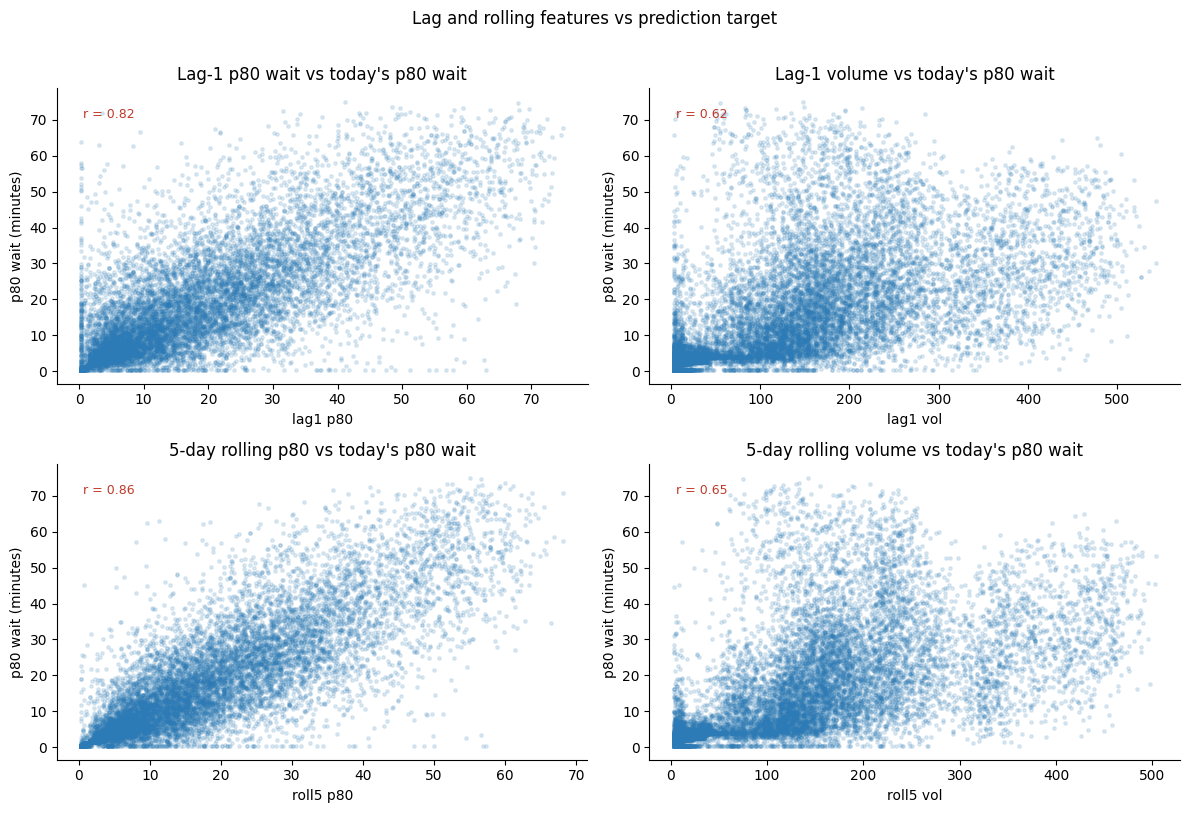

In [9]:
# Visualize lag feature distributions and their relationship to the target
rng = np.random.default_rng(42)
df_nonull = df.dropna(subset=lag_cols).copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
pairs = [
    ("lag1_p80",  "p80_wait_min", "Lag-1 p80 wait vs today's p80 wait"),
    ("lag1_vol",  "p80_wait_min", "Lag-1 volume vs today's p80 wait"),
    ("roll5_p80", "p80_wait_min", "5-day rolling p80 vs today's p80 wait"),
    ("roll5_vol", "p80_wait_min", "5-day rolling volume vs today's p80 wait"),
]

for ax, (xcol, ycol, title) in zip(axes.flat, pairs):
    ax.scatter(
        df_nonull[xcol], df_nonull[ycol],
        alpha=0.15, s=6, color="#2c7bb6", rasterized=True,
    )
    corr = df_nonull[[xcol, ycol]].corr().iloc[0, 1]
    ax.annotate(
        f"r = {corr:.2f}",
        xy=(0.05, 0.90), xytext=(0, 0),
        xycoords="axes fraction", textcoords="offset points",
        fontsize=9, color="#c0392b",
    )
    ax.set_xlabel(xcol.replace("_", " "))
    ax.set_ylabel("p80 wait (minutes)")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Lag and rolling features vs prediction target", y=1.01)
fig.tight_layout()
fig.savefig(OUTF + "02_lag_correlation.png", dpi=150, bbox_inches="tight")
print("Saved -> outputs/figures/02_lag_correlation.png")

## 4. Branch identity encoding

`Branch ID` is a high-cardinality categorical variable with ~90 unique values. One-hot encoding would add 90 sparse columns and make linear models brittle; raw label encoding would impose a false ordinal relationship. Instead, we apply smoothed target encoding: each branch is replaced by a weighted combination of its own historical mean p80 wait and the global mean. The smoothing factor (30 observations) ensures that branches with few training records are pulled toward the global mean rather than overfit to noisy local estimates.

This encoding is fit strictly on the training split and applied to the test split to prevent leakage.

In [10]:
# Drop rows with null lag features before splitting
df_model = df.dropna(subset=lag_cols).copy()
print(f"Modeling rows after dropping lag nulls: {len(df_model):,}")

# Time-based 80/20 split on unique dates
dates  = df_model["Visit Date"].sort_values().unique()
cutoff = dates[int(len(dates) * 0.80)]

train_mask = df_model["Visit Date"] < cutoff
df_train   = df_model[train_mask].copy()
df_test    = df_model[~train_mask].copy()

print(f"Train: {len(df_train):,} rows  ({df_train['Visit Date'].min().date()} to {df_train['Visit Date'].max().date()})")
print(f"Test:  {len(df_test):,} rows  ({df_test['Visit Date'].min().date()} to {df_test['Visit Date'].max().date()})")

Modeling rows after dropping lag nulls: 16,647
Train: 13,388 rows  (2024-01-04 to 2025-07-15)
Test:  3,259 rows  (2025-07-16 to 2025-11-29)


In [11]:
# Smoothed target encoding - fit on train, apply to test
SMOOTHING    = 30
global_mean  = df_train["p80_wait_min"].mean()

branch_stats = df_train.groupby("Branch ID")["p80_wait_min"].agg(["mean", "count"])
branch_te    = (
    (branch_stats["count"] * branch_stats["mean"] + SMOOTHING * global_mean)
    / (branch_stats["count"] + SMOOTHING)
)

df_train["branch_te"] = df_train["Branch ID"].map(branch_te).fillna(global_mean)
df_test["branch_te"]  = df_test["Branch ID"].map(branch_te).fillna(global_mean)

print(f"Branch target encoding range: {branch_te.min():.1f} - {branch_te.max():.1f} min")
print(f"Global mean used for unseen branches: {global_mean:.1f} min")

Branch target encoding range: 1.9 - 39.4 min
Global mean used for unseen branches: 13.1 min


## 5. Feature matrix definition and train-test split

The final feature set combines current-day operational inputs (volume, appointment type), engineered temporal signals (lags, rolling averages, cyclical calendar), and branch-level context (target-encoded identity, deployment model, region). `avg_wait_min` is excluded from features because it is derived from the same transactions as the target and would constitute leakage in a real deployment scenario.

In [12]:
NUM_FEATURES = [
    "daily_volume",    # current-day transaction count
    "lag1_p80",        # yesterday's p80 wait at this branch
    "lag1_vol",        # yesterday's transaction volume
    "roll5_p80",       # 5-day rolling mean p80 wait
    "roll5_vol",       # 5-day rolling mean volume
    "month",           # month of year (1-12)
    "week_of_year",    # ISO week number
    "dow_sin",         # cyclical day-of-week (sine)
    "dow_cos",         # cyclical day-of-week (cosine)
    "is_appt_day",     # 1 if majority visit type was Appointment
    "branch_te",       # smoothed branch mean wait (target encoded)
]
CAT_FEATURES = ["region", "site_type"]
FEATURE_COLS = NUM_FEATURES + CAT_FEATURES
TARGET       = "p80_wait_min"

X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET]
X_test  = df_test[FEATURE_COLS]
y_test  = df_test[TARGET]

print(f"Features:  {len(FEATURE_COLS)} ({len(NUM_FEATURES)} numeric, {len(CAT_FEATURES)} categorical)")
print(f"X_train:   {X_train.shape}  |  X_test: {X_test.shape}")

Features:  13 (11 numeric, 2 categorical)
X_train:   (13388, 13)  |  X_test: (3259, 13)


## 6. Ridge regression baseline

A regularized linear model serves as the performance floor. Ridge applies L2 regularization, which shrinks large coefficients toward zero and stabilizes the model when features are correlated - which they are here, since lag features and rolling means both track recent wait-time levels. Categorical features are one-hot encoded; numeric features are standardized so that regularization applies equally across scales.

A meaningful baseline for this problem is a model that always predicts the training mean (R² = 0 by definition). Any R² above zero represents signal captured beyond that naive benchmark.

In [14]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES),
])

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model",        Ridge(alpha=10.0)),
])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)

r2_ridge   = r2_score(y_test, y_pred_ridge)
mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Ridge (test set)")
print(f"  R2   : {r2_ridge:.4f}")
print(f"  MAE  : {mae_ridge:.3f} min")
print(f"  RMSE : {rmse_ridge:.3f} min")

Ridge (test set)
  R2   : 0.7252
  MAE  : 6.123 min
  RMSE : 8.860 min


Saved -> outputs/figures/02_ridge_actual_vs_pred.png


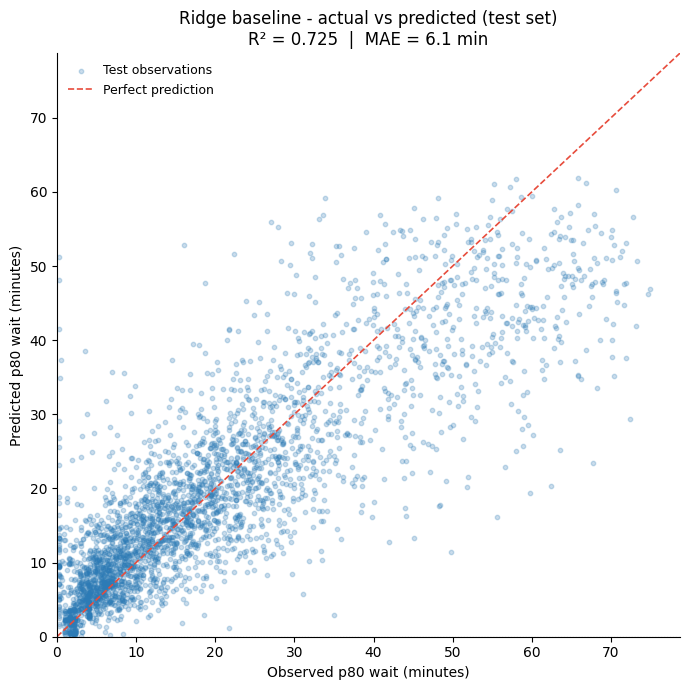

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, y_pred_ridge, alpha=0.25, s=10,
           color="#2c7bb6", rasterized=True, label="Test observations")

lim = max(y_test.max(), y_pred_ridge.max()) * 1.05
ax.plot([0, lim], [0, lim], ls="--", lw=1.2, color="#e74c3c", label="Perfect prediction")
ax.axhline(0, color="black", lw=0.8, ls=":", alpha=0.5)

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Observed p80 wait (minutes)")
ax.set_ylabel("Predicted p80 wait (minutes)")
ax.set_title(f"Ridge baseline - actual vs predicted (test set)\nR² = {r2_ridge:.3f}  |  MAE = {mae_ridge:.1f} min")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(OUTF + "02_ridge_actual_vs_pred.png", dpi=150, bbox_inches="tight")
print("Saved -> outputs/figures/02_ridge_actual_vs_pred.png")

## 7. Random Forest

A Random Forest captures nonlinear interactions between features - for example, the effect of high daily volume may differ between appointment-heavy and walk-in-heavy branches in a way that a linear model cannot represent without hand-crafted interaction terms. The branch target encoding replaces the high-cardinality `Branch ID` identifier with a continuous signal that the tree learner can split on without one-hot expansion.

`min_samples_leaf=5` prevents individual trees from memorizing small groups of branch-days, which is the main overfitting risk in a panel dataset of this type.

In [16]:
preprocessor_rf = ColumnTransformer([
    ("num", "passthrough", NUM_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES),
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42,
    )),
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"Random Forest (test set)")
print(f"  R2   : {r2_rf:.4f}")
print(f"  MAE  : {mae_rf:.3f} min")
print(f"  RMSE : {rmse_rf:.3f} min")

Random Forest (test set)
  R2   : 0.7316
  MAE  : 5.997 min
  RMSE : 8.756 min


Saved -> outputs/figures/02_rf_actual_vs_pred.png


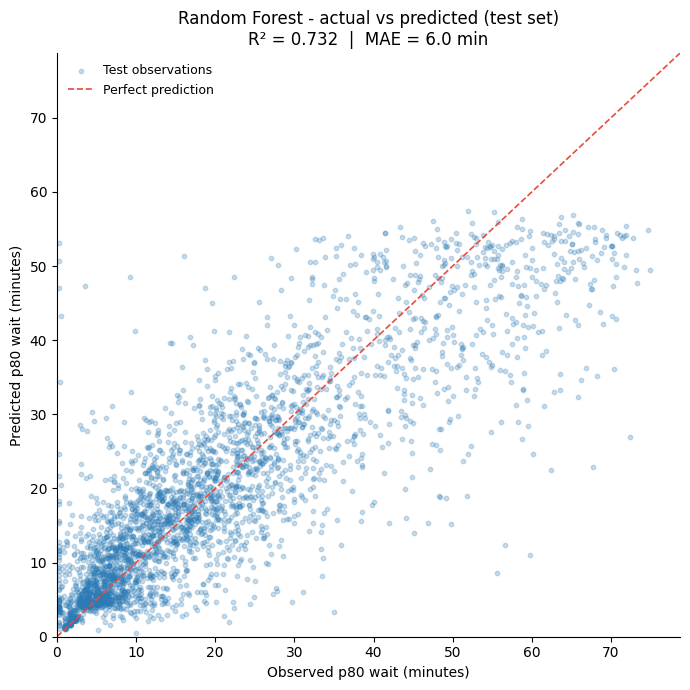

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, y_pred_rf, alpha=0.25, s=10,
           color="#2c7bb6", rasterized=True, label="Test observations")

lim = max(y_test.max(), y_pred_rf.max()) * 1.05
ax.plot([0, lim], [0, lim], ls="--", lw=1.2, color="#e74c3c", label="Perfect prediction")
ax.axhline(0, color="black", lw=0.8, ls=":", alpha=0.5)

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("Observed p80 wait (minutes)")
ax.set_ylabel("Predicted p80 wait (minutes)")
ax.set_title(f"Random Forest - actual vs predicted (test set)\nR² = {r2_rf:.3f}  |  MAE = {mae_rf:.1f} min")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(OUTF + "02_rf_actual_vs_pred.png", dpi=150, bbox_inches="tight")
print("Saved -> outputs/figures/02_rf_actual_vs_pred.png")

## 8. Permutation feature importance

Permutation importance measures how much model performance drops when a single feature's values are randomly shuffled on the held-out test set. A large drop means the model relied heavily on that feature; a near-zero drop means the feature was redundant or irrelevant. This approach is model-agnostic and avoids the bias of tree-native impurity-based importance, which systematically overstates the importance of high-cardinality numeric features.

The 5-day rolling mean of p80 wait dominates all other features - a branch's recent wait-time trajectory is far more informative than any structural attribute. This has a practical implication: a branch that has been running hot for five days is very likely to run hot today, regardless of its deployment model or region.

Saved -> outputs/figures/02_permutation_importance.png


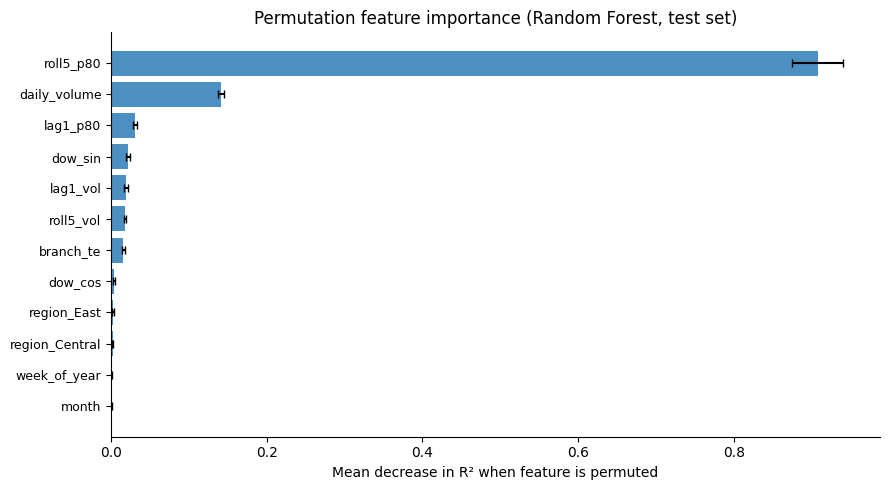

In [18]:
perm = permutation_importance(
    rf_pipeline, X_test, y_test,
    n_repeats=10, random_state=42, n_jobs=-1,
)

# Reconstruct feature names after OHE
ohe_names  = list(
    rf_pipeline.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(CAT_FEATURES)
)
all_names = NUM_FEATURES + ohe_names

# Keep top features for readability
N_SHOW = 12
idx = perm.importances_mean.argsort()[::-1][:N_SHOW]

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    range(N_SHOW),
    perm.importances_mean[idx][::-1],
    xerr=perm.importances_std[idx][::-1],
    color="#2c7bb6", alpha=0.85, capsize=3,
)
ax.set_yticks(range(N_SHOW))
ax.set_yticklabels([all_names[i] for i in idx][::-1], fontsize=9)
ax.set_xlabel("Mean decrease in R² when feature is permuted")
ax.set_title("Permutation feature importance (Random Forest, test set)")
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(OUTF + "02_permutation_importance.png", dpi=150, bbox_inches="tight")
print("Saved -> outputs/figures/02_permutation_importance.png")

## 9. Save feature matrix and model

The feature matrix (including all lag and rolling columns) is saved for use in Notebook 03, which adds XGBoost and SHAP-based explainability. The trained Random Forest pipeline is serialized so that Notebook 04 can load it directly for branch-level forecasting without re-training.

In [19]:
# Save feature matrix
df_model["branch_te"] = df_model["Branch ID"].map(branch_te).fillna(global_mean)
feature_save_cols = ["Branch ID", "Visit Date", TARGET] + FEATURE_COLS
df_model[feature_save_cols].to_csv(PROC + "daily_branch_features.csv", index=False)
print(f"Saved -> data/processed/daily_branch_features.csv  ({len(df_model):,} rows)")

# Save model
joblib.dump(rf_pipeline, OUTM + "rf_wait_time_pipeline.joblib")
print("Saved -> models/rf_wait_time_pipeline.joblib")

Saved -> data/processed/daily_branch_features.csv  (16,647 rows)
Saved -> models/rf_wait_time_pipeline.joblib


## Summary

| Item | Detail |
|---|---|
| Feature count | 13 features: 11 numeric, 2 one-hot encoded categorical |
| Key engineered features | 5-day rolling p80 wait, lag-1 p80 wait, smoothed branch target encoding |
| Temporal leakage prevention | All lags shifted by 1 day; target encoding fit on train split only; test set starts 2025-07-16 |
| Ridge baseline | R² = 0.73, MAE = 6.12 min, RMSE = 8.86 min |
| Random Forest | R² = 0.73, MAE = 6.00 min, RMSE = 8.76 min |
| Top feature (permutation) | `roll5_p80` - 5-day rolling mean p80 wait, importance score 0.91 |
| RF vs Ridge gap | Minimal at this stage - both models are primarily autoregressive; the nonlinear lift from RF is small until hyperparameter tuning and XGBoost are introduced in Notebook 03 |
| Key insight | Recent wait-time history dominates all structural features; `daily_volume` is the only current-day input with meaningful importance (0.14), confirming that operational context adds signal beyond the autoregressive baseline |

Next: **Notebook 03** adds XGBoost, cross-validated model comparison, and SHAP waterfall plots to identify which features drive predictions for individual branch-days.